In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import sys
sys.path.append('../../1_figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils

large_data_dir = gf_utils.large_data_dir

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
import matplotlib.pyplot as plt
import scipy.stats as st


In [ ]:
for i in [1,2]: ### barcode 1 is no decrosslink, barcode 2 is 80C decrosslink
    gf_dir = large_data_dir + 'gf_decrosslink_4plex/BC' + str(i) + '_giftwrap/'
    adata_path = large_data_dir + 'GBM_BC00' + str(i) + '_genotyped.h5ad'
    
    manifest = pd.read_csv('../data/glioma_manifest.tsv',sep='\t',index_col=0)
    manifest = manifest.loc[manifest['name'] != 'ATRX 0bp_0'] ### exclude because it is missing for both BC2 libraries, suggesting opool issue

    probe_reads = gf_utils.get_input_probe_reads(gf_dir, read_threshold = 50, min_percent_supporting = -1, adata_path = adata_path, collapse_across_probes=True)
    probe_reads = probe_reads.merge(manifest[['name','gene','gapfill_from_transcriptome','gap_probe_sequence']], left_on = 'probe_idx', right_index=True)

    adata = sc.read_h5ad(adata_path)

    probe_counts_per_cell = (probe_reads['name'].value_counts() / adata.n_obs).reindex(manifest['name']).fillna(0)
    probe_counts_per_cell.name = 'BC' + str(i)

    if i == 1:
        probe_counts_df = probe_counts_per_cell.to_frame()
    else:
        probe_counts_df = probe_counts_df.join(probe_counts_per_cell.to_frame())


73446 UMIs found
Collapsing UMIs across probes, 73446 UMIs remaining (100.00%)
Filtering probe reads based on read threshold (50) and min percent supporting (-1), 56107 UMIs remaining (76.39%)
Filtering cells based on min counts (0) and genes (0) in WTA
Filtering probe reads based on cell barcodes in adata, 35673 UMIs remaining (48.57%)
819118 UMIs found
Collapsing UMIs across probes, 819118 UMIs remaining (100.00%)
Filtering probe reads based on read threshold (50) and min percent supporting (-1), 638840 UMIs remaining (77.99%)
Filtering cells based on min counts (0) and genes (0) in WTA
Filtering probe reads based on cell barcodes in adata, 608248 UMIs remaining (74.26%)


/tmp/ipykernel_2009032/3446450160.py:19: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


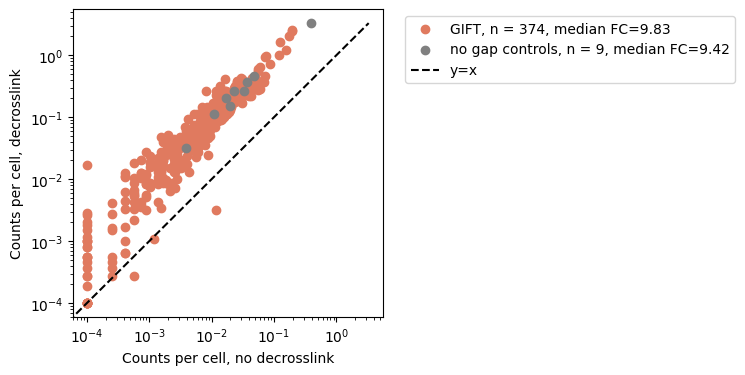

In [3]:
fig,ax = plt.subplots(figsize=(4,4))

median_FC = (probe_counts_df.loc[~probe_counts_df.index.str.contains('0bp'),'BC2'] / probe_counts_df.loc[~probe_counts_df.index.str.contains('0bp'),'BC1']).median()
ax.scatter(probe_counts_df.loc[~probe_counts_df.index.str.contains('0bp'),'BC1'] + 0.0001, probe_counts_df.loc[~probe_counts_df.index.str.contains('0bp'),'BC2'] + 0.0001, color = '#E07A5F', label='GIFT, n = ' + str(probe_counts_df.loc[~probe_counts_df.index.str.contains('0bp'),'BC1'].count()) + ', median FC=' + str(round(median_FC,2)))

median_FC = (probe_counts_df.loc[probe_counts_df.index.str.contains('0bp'),'BC2'] / probe_counts_df.loc[probe_counts_df.index.str.contains('0bp'),'BC1']).median()
ax.scatter(probe_counts_df.loc[probe_counts_df.index.str.contains('0bp'),'BC1'] + 0.0001, probe_counts_df.loc[probe_counts_df.index.str.contains('0bp'),'BC2'] + 0.0001, color = 'grey', label='no gap controls, n = ' + str(probe_counts_df.loc[probe_counts_df.index.str.contains('0bp'),'BC1'].count()) + ', median FC=' + str(round(median_FC,2)))

ax.set_xscale('log')
ax.set_yscale('log')

ax.plot([probe_counts_df.min().min(), probe_counts_df.max().max()], 
    [probe_counts_df.min().min(), probe_counts_df.max().max()], 
    'k--', alpha=1, label='y=x')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xlabel('Counts per cell, no decrosslink')
ax.set_ylabel('Counts per cell, decrosslink')

plt.tight_layout()

plt.savefig('../plots/gapfill_counts_dcl_comparison.pdf')

In [4]:
st.wilcoxon(probe_counts_df.loc[~probe_counts_df.index.str.contains('0bp'),'BC1'], probe_counts_df.loc[~probe_counts_df.index.str.contains('0bp'),'BC2'], alternative='less')

WilcoxonResult(statistic=88.0, pvalue=6.93061963742921e-62)

In [5]:
st.wilcoxon(probe_counts_df.loc[probe_counts_df.index.str.contains('0bp'),'BC1'], probe_counts_df.loc[probe_counts_df.index.str.contains('0bp'),'BC2'], alternative='less')

WilcoxonResult(statistic=0.0, pvalue=0.001953125)

In [6]:
probe_counts_df.to_csv('../output/gift_probe_counts_per_cell.csv')